In [1]:
from src.backend import TorchBackend
from src.model import Rectangle, Ellipse, Material, Lattice, Bitmap, Layer, Source

import torch
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%%bash
nvidia-smi

Tue Jan 27 10:55:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:41:00.0 Off |                  Off |
| 30%   43C    P0            111W /  480W |   14094MiB /  24564MiB |    100%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
dtype = torch.float64
backend = TorchBackend(device=device, dtype=dtype)

period = (500, 500)
grid = (201, 201)
M = 21
N = 21
lattice = Lattice(period=period, grid=grid, M=M, N=N)

In [4]:
epsilon = torch.nn.Parameter(torch.tensor([4.0 + 0.1j]), requires_grad=True)
epsilon_bg = torch.nn.Parameter(torch.tensor([1.0]), requires_grad=True)
mat = Material(epsilon)
mat_bg = Material(epsilon_bg)

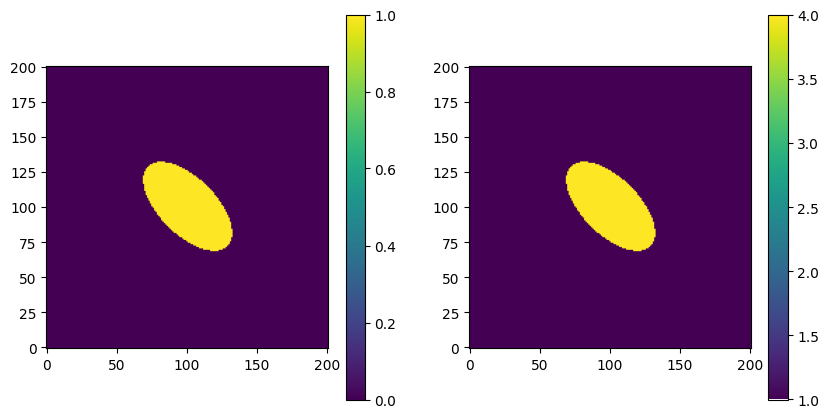

In [5]:
center = torch.nn.Parameter(torch.tensor([0.0, 0.0]), requires_grad=True)
size = torch.nn.Parameter(torch.tensor([100.0, 200.0]), requires_grad=True)
angle = torch.nn.Parameter(torch.tensor(45.0*torch.pi/180), requires_grad=True)
obj = Ellipse(center=center, size=size, angle=angle, 
                material=mat, soft_mask=False, smoothness=0.005)

epsilon_xy = obj.epsilon_xy(backend, lattice, mat_bg)
bitmap = obj.bitmap(backend, lattice)
print(epsilon_xy.grad_fn)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(bitmap.real.detach().cpu().numpy().T, origin='lower')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(epsilon_xy[0,0,0].real.detach().cpu().numpy().T, origin='lower')
plt.colorbar()

epsilon_xy shape: torch.Size([1, 3, 3, 201, 201])
Error: 0.00028442368519862593


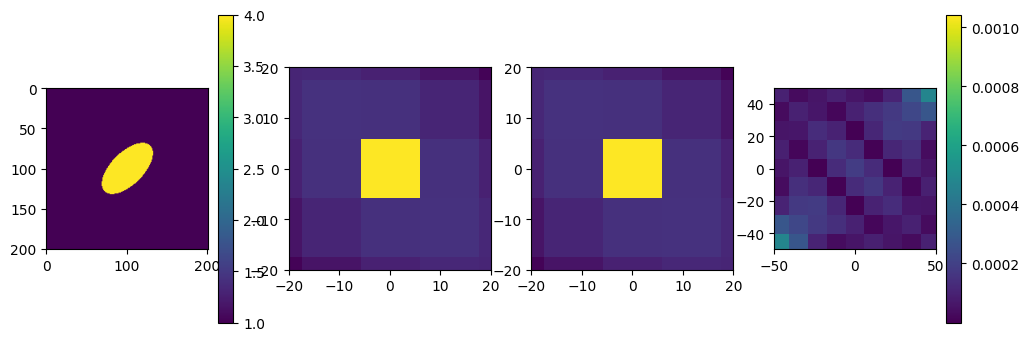

In [6]:
epsilon_mn = obj.epsilon_mn(backend, lattice, mat_bg, closed_form=True)
epsilon_f = obj.epsilon_mn(backend, lattice, mat_bg, closed_form=False)
print("epsilon_xy shape:", epsilon_xy.shape)

plt.figure(figsize=(12,4))

plt.subplot(141)
plt.imshow(epsilon_xy[0,0,0].cpu().detach().numpy().real)
plt.colorbar()

plt.subplot(142)
plt.imshow(backend.abs(epsilon_f[0,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(143)
plt.imshow(backend.abs(epsilon_mn[0,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(144)
plt.imshow(backend.abs(epsilon_mn[0,0,0] - epsilon_f[0,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.colorbar()

error = torch.sqrt(torch.mean(backend.abs((epsilon_mn[0,0,0] - epsilon_f[0,0,0])**2)))
print(f'Error: {error}')

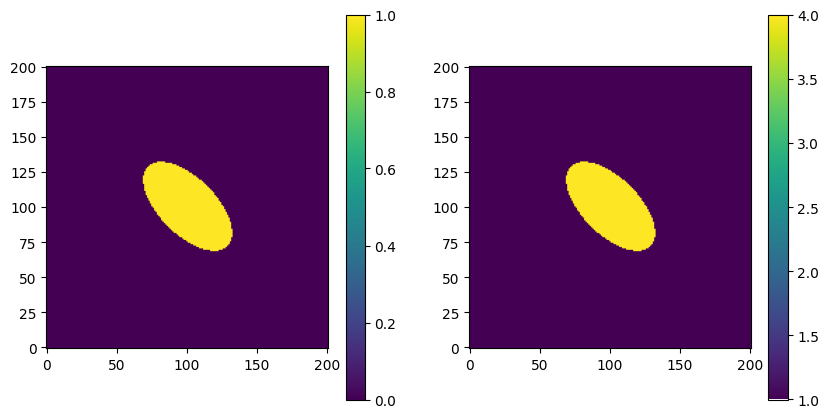

In [7]:
bitmap_t = torch.from_numpy(bitmap.cpu().numpy())
bitmap_new = torch.nn.Parameter(bitmap_t, requires_grad=True)

bitmap_obj = Bitmap(bitmap=bitmap_new, material=mat)

epsilon_xy2 = bitmap_obj.epsilon_xy(backend, lattice, mat_bg)
bitmap2 = bitmap_obj.bitmap(backend, lattice)
print(epsilon_xy2.grad_fn)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(bitmap2.real.detach().cpu().numpy().T, origin='lower')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(epsilon_xy2[0,0,0].real.detach().cpu().numpy().T, origin='lower')
plt.colorbar()

epsilon_xy shape: torch.Size([1, 3, 3, 201, 201])
Error: 0.0


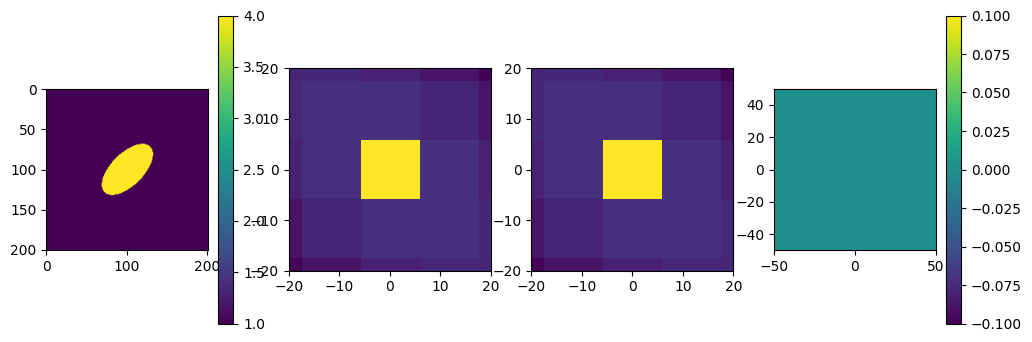

In [9]:
epsilon_mn2 = bitmap_obj.epsilon_mn(backend, lattice, mat_bg, closed_form=True)
epsilon_f2 = bitmap_obj.epsilon_mn(backend, lattice, mat_bg, closed_form=False)
print("epsilon_xy shape:", epsilon_xy2.shape)

plt.figure(figsize=(12,4))

plt.subplot(141)
plt.imshow(epsilon_xy2[0,0,0].cpu().detach().numpy().real)
plt.colorbar()

plt.subplot(142)
plt.imshow(backend.abs(epsilon_f2[0,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(143)
plt.imshow(backend.abs(epsilon_mn2[0,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-20, 20)
plt.ylim(-20, 20)

plt.subplot(144)
plt.imshow(backend.abs(epsilon_mn2[0,0,0] - epsilon_f2[0,0,0]).cpu().detach().numpy(), extent=(-lattice.period[0]/2, lattice.period[0]/2, -lattice.period[1]/2, lattice.period[1]/2))
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.colorbar()

error = torch.sqrt(torch.mean(backend.abs((epsilon_mn2[0,0,0] - epsilon_f2[0,0,0])**2)))
print(f'Error: {error}')

In [10]:
# Assemble layer
d = torch.nn.Parameter(torch.tensor(300.0), requires_grad=True)
layer = Layer(thickness=d, objects=obj, material_bg=mat_bg)

epsilon_mn = layer.epsilon_mn(backend, lattice, closed_form=True)
epsilon_xy = layer.epsilon_xy(backend, lattice)

print(layer.is_homogeneous(backend, lattice))
print(layer.is_magnetic)
print(layer.is_semi_infinite)
print(epsilon_xy.shape)
print(layer.mu_xy(backend, lattice).shape)
print(epsilon_mn.shape)
print(layer.mu_mn(backend, lattice).shape)

loss = epsilon_mn.real.sum()   # make sure loss is a real scalar
loss.backward()

print(center.grad)
print(size.grad)
print(angle.grad)
print(epsilon.grad)
print(epsilon_bg.grad)
print(d.grad)

False
False
False
torch.Size([1, 3, 3, 201, 201])
torch.Size([1, 3, 3, 201, 201])
torch.Size([1, 3, 3, 43, 43])
torch.Size([1, 3, 3, 43, 43])
tensor([2.8915e-09, 2.8915e-09])
tensor([-0.0031,  0.0044])
tensor(-8.1597e-08)
tensor([-0.0011-1.4968e-23j])
tensor([3.0011])
None


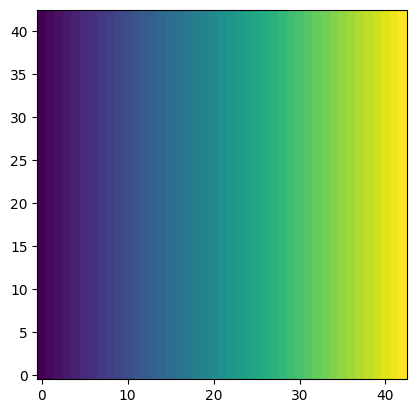

In [11]:
# Create Source
wavelength = torch.tensor([400, 500, 600])
theta = torch.tensor([0.0, 10.0])  # normal incidence
phi = torch.tensor([10.0])    # azimuthal angle

n_inc = 1.0#torch.ones_like(wavelength)

src = Source(wavelength=wavelength, theta=theta, phi=phi)
k0x, k0y = src.k0xy(backend, n_inc, reduced=False)
Kx, Ky = src.Kxy(backend, lattice, n_inc)
plt.imshow(Kx[0,0,0].cpu().T, origin='lower')